In [3]:
print("""
06 GEOMETRY
     │
     ▼
07 AERODYNAMICS
     │
     ├── CL
     ├── CD
     ├── Drag
     └── Required Power
             │
             ▼
08 PROPULSION
     │
     ├── Engine Power
     ├── Altitude Effect
     ├── Propeller Efficiency
     └── Available Power
             │
             ▼
09 PERFORMANCE
     │
     ├── Stall Speed
     ├── Cruise
     ├── Excess Power
     ├── Rate of Climb
     ├── Maximum Speed
     ├── Service Ceiling
     └── Performance Maps
     """)


06 GEOMETRY
     │
     ▼
07 AERODYNAMICS
     │
     ├── CL
     ├── CD
     ├── Drag
     └── Required Power
             │
             ▼
08 PROPULSION
     │
     ├── Engine Power
     ├── Altitude Effect
     ├── Propeller Efficiency
     └── Available Power
             │
             ▼
09 PERFORMANCE
     │
     ├── Stall Speed
     ├── Cruise
     ├── Excess Power
     ├── Rate of Climb
     ├── Maximum Speed
     ├── Service Ceiling
     └── Performance Maps
     


In [1]:
# ============================================================
# TBM-X — 09 PERFORMANCE MODEL
# ============================================================
#
# Objective:
# Evaluate aircraft performance using the aerodynamic
# and propulsion models developed in Sections 07 and 08..
#
# Main outputs:
#
#   1. Stall speed
#   2. Required power
#   3. Available power
#   4. Excess power
#   5. Rate of climb
#   6. Maximum level-flight speed
#   7. Service ceiling
#   8. Performance sensitivity
#
# Architecture:
#
#       AERODYNAMICS (07)
#              │
#              ▼
#       Required Power
#              │
#              ├──────────────┐
#              │              │
#              ▼              ▼
#       PROPULSION (08)    PERFORMANCE
#              │
#       Available Power
#
# Philosophy:
# Raymer + Physics + Benchmark + Engineering Assumptions
# ============================================================

**Libraries**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

**Working Directory**

In [6]:
PROJECT_ROOT = Path.cwd()

print("Project root:")
print(PROJECT_ROOT)

Project root:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering


**Aircraft Design Inputs**

In [7]:
# ============================================================
# TBM-X DESIGN VECTOR
# ============================================================

MTOW_kg = 3400.0

wing_area_m2 = 18.0
aspect_ratio = 9.15

taper_ratio = 0.45

CLmax_landing = 1.80

print(f"MTOW             : {MTOW_kg:.1f} kg")
print(f"Wing area        : {wing_area_m2:.2f} m²")
print(f"Aspect ratio     : {aspect_ratio:.2f}")
print(f"CLmax landing    : {CLmax_landing:.2f}")

MTOW             : 3400.0 kg
Wing area        : 18.00 m²
Aspect ratio     : 9.15
CLmax landing    : 1.80


**Aircraft Weight**

In [8]:
# ------------------------------------------------------------
# Weight
# ------------------------------------------------------------

g = 9.80665

mass_kg = MTOW_kg

weight_N = mass_kg * g

print(f"Weight = {weight_N:.0f} N")

Weight = 33343 N


**Flight Conditions**

In [9]:
# ============================================================
# REFERENCE FLIGHT CONDITION
# ============================================================

cruise_speed_kt = 300.0
cruise_altitude_ft = 25000.0

KT_TO_MS = 0.514444
FT_TO_M = 0.3048

cruise_speed_m_s = (
    cruise_speed_kt * KT_TO_MS
)

cruise_altitude_m = (
    cruise_altitude_ft * FT_TO_M
)

print(f"Cruise speed    : {cruise_speed_m_s:.2f} m/s")
print(f"Cruise altitude : {cruise_altitude_m:.0f} m")

Cruise speed    : 154.33 m/s
Cruise altitude : 7620 m


**ISA Atmosphere**

In [10]:
# ============================================================
# ISA ATMOSPHERE
# ============================================================

def isa_atmosphere(altitude_m):
    """
    Simplified ISA atmosphere model.

    Returns:
        T   : temperature [K]
        P   : pressure [Pa]
        rho : density [kg/m³]
    """

    T0 = 288.15
    P0 = 101325.0

    lapse_rate = 0.0065
    R = 287.05
    g = 9.80665

    T = T0 - lapse_rate * altitude_m

    P = P0 * (
        T / T0
    ) ** (
        g / (R * lapse_rate)
    )

    rho = P / (R * T)

    return T, P, rho

**Aerodynamic Parameters**

In [11]:
# ============================================================
# AERODYNAMIC MODEL PARAMETERS
# ============================================================

CD0 = 0.025

oswald_efficiency = 0.80

k = (
    1.0 /
    (
        np.pi *
        oswald_efficiency *
        aspect_ratio
    )
)

print(f"CD0 = {CD0:.4f}")
print(f"e   = {oswald_efficiency:.2f}")
print(f"k   = {k:.5f}")

CD0 = 0.0250
e   = 0.80
k   = 0.04348


**Propulsion Parameters**

In [12]:
# ============================================================
# PROPULSION MODEL PARAMETERS
# ============================================================

engine_rated_power_kW = 650.0

propeller_efficiency = 0.85

BSFC_kg_kWh = 0.30

critical_altitude_ratio = 0.40
altitude_power_exponent = 0.70

print(f"Rated engine power : {engine_rated_power_kW:.1f} kW")
print(f"Propeller ηp       : {propeller_efficiency:.2f}")
print(f"BSFC               : {BSFC_kg_kWh:.3f} kg/kWh")

Rated engine power : 650.0 kW
Propeller ηp       : 0.85
BSFC               : 0.300 kg/kWh


**Altitude Power Model**

In [13]:
# ============================================================
# ENGINE ALTITUDE POWER MODEL
# ============================================================

def altitude_power_factor(
    density_ratio,
    critical_altitude_ratio=0.40,
    exponent=0.70
):
    """
    Conceptual altitude correction for turboprop
    available shaft power.
    """

    if density_ratio >= critical_altitude_ratio:
        return 1.0

    return (
        density_ratio /
        critical_altitude_ratio
    ) ** exponent

**Aerodynamic Calculation Function**

In [14]:
# ============================================================
# AERODYNAMIC PERFORMANCE FUNCTION
# ============================================================

def aerodynamic_performance(
    speed_m_s,
    altitude_m,
    weight_N,
    wing_area_m2,
    CD0,
    k
):
    """
    Calculate aerodynamic performance at a given
    speed and altitude.
    """

    T, P, rho = isa_atmosphere(
        altitude_m
    )

    q = 0.5 * rho * speed_m_s**2

    CL = (
        weight_N /
        (q * wing_area_m2)
    )

    CD = (
        CD0 +
        k * CL**2
    )

    drag_N = (
        q *
        wing_area_m2 *
        CD
    )

    L_D = CL / CD

    required_shaft_power_kW = (
        drag_N *
        speed_m_s /
        propeller_efficiency /
        1000
    )

    return {
        "T_K": T,
        "P_Pa": P,
        "rho_kg_m3": rho,
        "q_Pa": q,
        "CL": CL,
        "CD": CD,
        "drag_N": drag_N,
        "L_D": L_D,
        "required_shaft_power_kW":
            required_shaft_power_kW
    }

**Propulsion Calculation Function**

In [15]:
# ============================================================
# PROPULSION PERFORMANCE FUNCTION
# ============================================================

def available_shaft_power(
    altitude_m,
    engine_rated_power_kW
):
    """
    Calculate available engine shaft power
    at a given altitude.
    """

    _, _, rho = isa_atmosphere(
        altitude_m
    )

    rho_sl = 1.225

    sigma = rho / rho_sl

    factor = altitude_power_factor(
        sigma,
        critical_altitude_ratio,
        altitude_power_exponent
    )

    available_power_kW = (
        engine_rated_power_kW *
        factor
    )

    return {
        "rho_kg_m3": rho,
        "sigma": sigma,
        "power_factor": factor,
        "available_shaft_power_kW":
            available_power_kW
    }

**Reference Cruise Calculation**

In [16]:
# ============================================================
# REFERENCE CRUISE PERFORMANCE
# ============================================================

aero = aerodynamic_performance(
    speed_m_s=cruise_speed_m_s,
    altitude_m=cruise_altitude_m,
    weight_N=weight_N,
    wing_area_m2=wing_area_m2,
    CD0=CD0,
    k=k
)

prop = available_shaft_power(
    altitude_m=cruise_altitude_m,
    engine_rated_power_kW=
        engine_rated_power_kW
)

print("=== CRUISE PERFORMANCE ===")

print(
    f"CL                   : "
    f"{aero['CL']:.3f}"
)

print(
    f"CD                   : "
    f"{aero['CD']:.4f}"
)

print(
    f"L/D                  : "
    f"{aero['L_D']:.2f}"
)

print(
    f"Required shaft power : "
    f"{aero['required_shaft_power_kW']:.1f} kW"
)

print(
    f"Available shaft power: "
    f"{prop['available_shaft_power_kW']:.1f} kW"
)

=== CRUISE PERFORMANCE ===
CL                   : 0.283
CD                   : 0.0285
L/D                  : 9.94
Required shaft power : 608.8 kW
Available shaft power: 650.0 kW


**Excess Power**

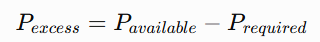

In [17]:
# ============================================================
# EXCESS POWER
# ============================================================

P_available_kW = (
    prop["available_shaft_power_kW"]
)

P_required_kW = (
    aero["required_shaft_power_kW"]
)

P_excess_kW = (
    P_available_kW -
    P_required_kW
)

print(
    f"Available power : {P_available_kW:.1f} kW"
)

print(
    f"Required power  : {P_required_kW:.1f} kW"
)

print(
    f"Excess power    : {P_excess_kW:.1f} kW"
)

Available power : 650.0 kW
Required power  : 608.8 kW
Excess power    : 41.2 kW


**Rate of Climb**

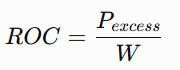

In [18]:
# ============================================================
# RATE OF CLIMB
# ============================================================

ROC_m_s = (
    P_excess_kW * 1000 /
    weight_N
)

ROC_ft_min = (
    ROC_m_s *
    196.850394
)

print(
    f"Rate of climb = "
    f"{ROC_m_s:.2f} m/s"
)

print(
    f"Rate of climb = "
    f"{ROC_ft_min:.0f} ft/min"
)

Rate of climb = 1.24 m/s
Rate of climb = 244 ft/min


**Stall Speed**

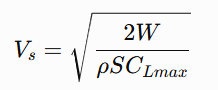

In [19]:
# ============================================================
# STALL SPEED
# ============================================================

rho_sl = 1.225

stall_speed_m_s = np.sqrt(
    (
        2 *
        weight_N
    ) /
    (
        rho_sl *
        wing_area_m2 *
        CLmax_landing
    )
)

stall_speed_kt = (
    stall_speed_m_s /
    KT_TO_MS
)

print(
    f"Stall speed = "
    f"{stall_speed_kt:.1f} kt"
)

Stall speed = 79.7 kt


**Speed Sweep**

In [20]:
# ============================================================
# SPEED SWEEP
# ============================================================

speed_kt_array = np.linspace(
    60,
    360,
    200
)

speed_ms_array = (
    speed_kt_array *
    KT_TO_MS
)

results = []

for V in speed_ms_array:

    aero_i = aerodynamic_performance(
        speed_m_s=V,
        altitude_m=cruise_altitude_m,
        weight_N=weight_N,
        wing_area_m2=wing_area_m2,
        CD0=CD0,
        k=k
    )

    results.append({
        "speed_kt": V / KT_TO_MS,
        "CL": aero_i["CL"],
        "CD": aero_i["CD"],
        "drag_N": aero_i["drag_N"],
        "L_D": aero_i["L_D"],
        "required_power_kW":
            aero_i["required_shaft_power_kW"]
    })

speed_results = pd.DataFrame(
    results
)

speed_results.head()

,speed_kt,CL,CD,drag_N,L_D,required_power_kW
0,60.000000,7.083517,2.206910,10388.081930,3.209698,377.229630
1,61.507538,6.740541,2.000734,9896.788135,3.369033,368.418810
2,63.015075,6.421885,1.818346,9440.904297,3.531718,360.061956
3,64.522613,6.125303,1.656527,9017.173772,3.697679,352.128817
4,66.030151,5.848801,1.512554,8622.707386,3.866838,344.591942


**Available Power at Cruise Altitude**

In [21]:
# ------------------------------------------------------------
# Available power at reference altitude
# ------------------------------------------------------------

available_power_cruise_kW = (
    P_available_kW
)

speed_results[
    "available_power_kW"
] = available_power_cruise_kW

speed_results[
    "excess_power_kW"
] = (
    speed_results[
        "available_power_kW"
    ]
    -
    speed_results[
        "required_power_kW"
    ]
)

**Power Required vs Speed**

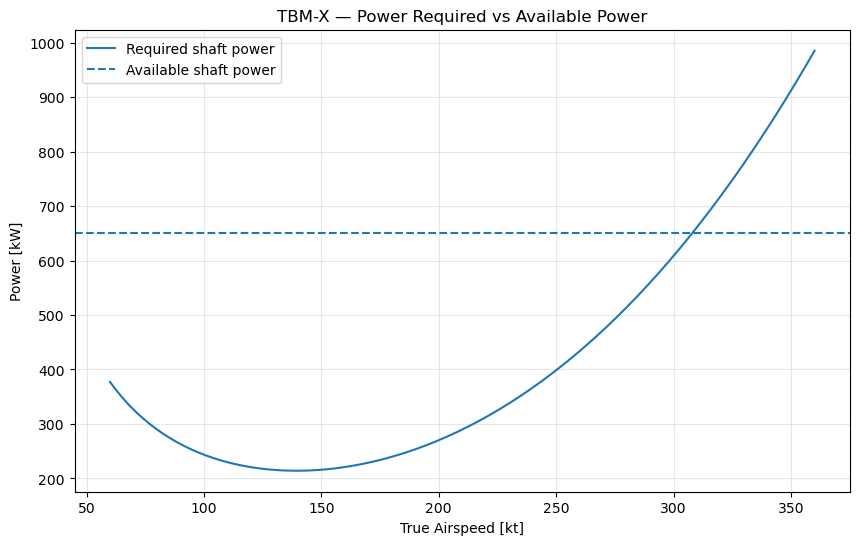

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    speed_results["speed_kt"],
    speed_results["required_power_kW"],
    label="Required shaft power"
)

plt.axhline(
    available_power_cruise_kW,
    linestyle="--",
    label="Available shaft power"
)

plt.xlabel("True Airspeed [kt]")
plt.ylabel("Power [kW]")
plt.title(
    "TBM-X — Power Required vs Available Power"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**Maximum Level-Flight Speed**

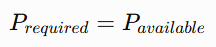

In [23]:
# ============================================================
# MAXIMUM LEVEL-FLIGHT SPEED
# ============================================================

valid_points = speed_results[
    speed_results["excess_power_kW"] >= 0
]

if len(valid_points) > 0:

    max_level_speed_kt = (
        valid_points["speed_kt"].max()
    )

    print(
        f"Maximum level-flight speed "
        f"≈ {max_level_speed_kt:.1f} kt"
    )

else:

    max_level_speed_kt = np.nan

    print(
        "No valid level-flight speed "
        "found in the selected range."
    )

Maximum level-flight speed ≈ 307.2 kt


**Maximum L/D**

In [24]:
# ============================================================
# MAXIMUM L/D
# ============================================================

idx_max_ld = (
    speed_results["L_D"].idxmax()
)

best_LD_speed_kt = (
    speed_results.loc[
        idx_max_ld,
        "speed_kt"
    ]
)

max_LD = (
    speed_results.loc[
        idx_max_ld,
        "L_D"
    ]
)

print(
    f"Maximum L/D = {max_LD:.2f}"
)

print(
    f"Speed for maximum L/D = "
    f"{best_LD_speed_kt:.1f} kt"
)

Maximum L/D = 15.16
Speed for maximum L/D = 183.6 kt


**Required Power Plot**

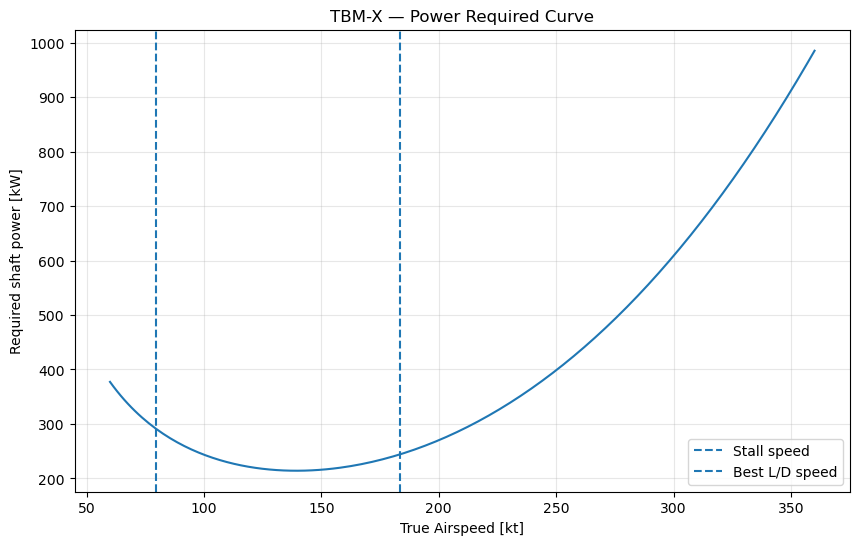

In [25]:
plt.figure(figsize=(10, 6))

plt.plot(
    speed_results["speed_kt"],
    speed_results["required_power_kW"]
)

plt.axvline(
    stall_speed_kt,
    linestyle="--",
    label="Stall speed"
)

plt.axvline(
    best_LD_speed_kt,
    linestyle="--",
    label="Best L/D speed"
)

plt.xlabel("True Airspeed [kt]")
plt.ylabel("Required shaft power [kW]")
plt.title("TBM-X — Power Required Curve")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**Excess Power Curve**

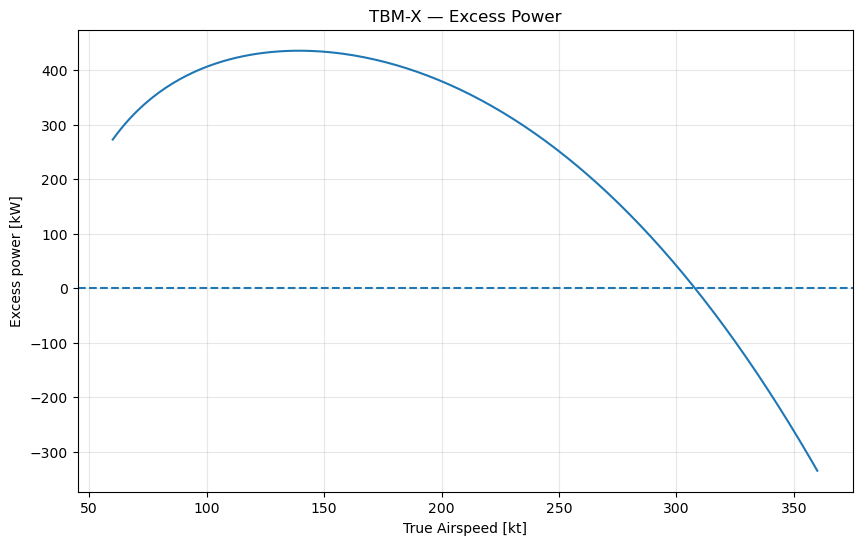

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(
    speed_results["speed_kt"],
    speed_results["excess_power_kW"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("True Airspeed [kt]")
plt.ylabel("Excess power [kW]")
plt.title("TBM-X — Excess Power")

plt.grid(True, alpha=0.3)

plt.show()

**Rate of Climb vs Speed**

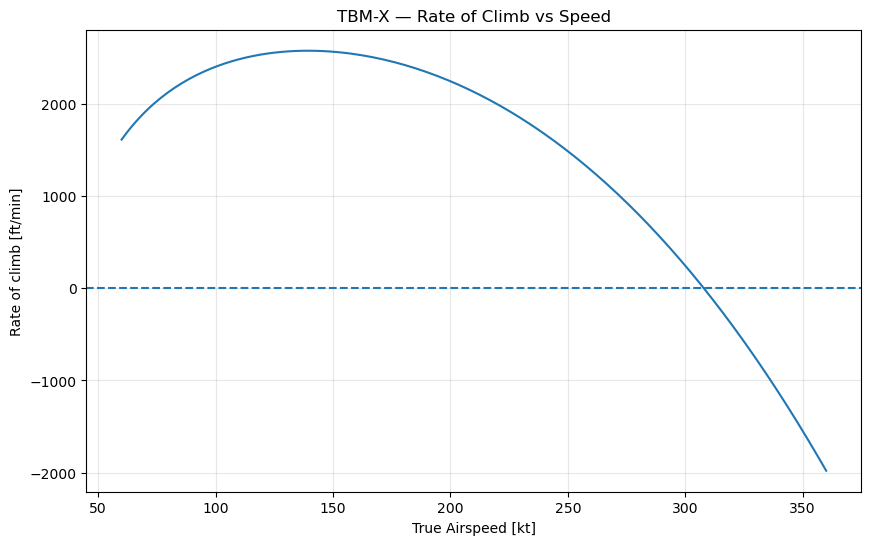

In [27]:
# ============================================================
# RATE OF CLIMB VS SPEED
# ============================================================

speed_results[
    "ROC_m_s"
] = (
    speed_results[
        "excess_power_kW"
    ] * 1000 /
    weight_N
)

speed_results[
    "ROC_ft_min"
] = (
    speed_results[
        "ROC_m_s"
    ] *
    196.850394
)

plt.figure(figsize=(10, 6))

plt.plot(
    speed_results["speed_kt"],
    speed_results["ROC_ft_min"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("True Airspeed [kt]")
plt.ylabel("Rate of climb [ft/min]")
plt.title(
    "TBM-X — Rate of Climb vs Speed"
)

plt.grid(True, alpha=0.3)

plt.show()

**Maximum Rate of Climb**

In [28]:
# ============================================================
# MAXIMUM RATE OF CLIMB
# ============================================================

idx_max_roc = (
    speed_results["ROC_ft_min"].idxmax()
)

max_ROC_ft_min = (
    speed_results.loc[
        idx_max_roc,
        "ROC_ft_min"
    ]
)

speed_max_ROC_kt = (
    speed_results.loc[
        idx_max_roc,
        "speed_kt"
    ]
)

print(
    f"Maximum ROC = "
    f"{max_ROC_ft_min:.0f} ft/min"
)

print(
    f"Speed for maximum ROC = "
    f"{speed_max_ROC_kt:.1f} kt"
)

Maximum ROC = 2573 ft/min
Speed for maximum ROC = 139.9 kt


**Service Ceiling Calculation**

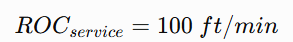

In [30]:
# ============================================================
# SERVICE CEILING
# ============================================================

service_ceiling_ROC_ft_min = 100.0

altitude_array_ft = np.linspace(
    0,
    40000,
    161
)

ceiling_results = []

for altitude_ft in altitude_array_ft:

    altitude_m = (
        altitude_ft *
        FT_TO_M
    )

    prop_i = available_shaft_power(
        altitude_m=altitude_m,
        engine_rated_power_kW=
            engine_rated_power_kW
    )

    available_i = (
        prop_i[
            "available_shaft_power_kW"
        ]
    )

    # Evaluate maximum climb capability
    # across the speed range
    roc_values = []

    for V in speed_ms_array:

        aero_i = aerodynamic_performance(
            speed_m_s=V,
            altitude_m=altitude_m,
            weight_N=weight_N,
            wing_area_m2=wing_area_m2,
            CD0=CD0,
            k=k
        )

        P_required_i = (
            aero_i[
                "required_shaft_power_kW"
            ]
        )

        excess_i = (
            available_i -
            P_required_i
        )

        roc_i = (
            excess_i * 1000 /
            weight_N
        )

        roc_values.append(
            roc_i * 196.850394
        )

    max_roc_i = max(
        roc_values
    )

    ceiling_results.append({
        "altitude_ft": altitude_ft,
        "available_power_kW":
            available_i,
        "max_ROC_ft_min":
            max_roc_i
    })

ceiling_results = pd.DataFrame(
    ceiling_results
)

In [31]:
ceiling_results

,altitude_ft,available_power_kW,max_ROC_ft_min
0,0.0,650.000000,2991.291356
1,250.0,650.000000,2988.159313
2,500.0,650.000000,2984.997069
3,750.0,650.000000,2981.913231
4,1000.0,650.000000,2978.777754
...,...,...,...
156,39000.0,487.047028,1231.108977
157,39250.0,483.647018,1202.819079
158,39500.0,480.262813,1174.508520
159,39750.0,476.894376,1146.261080


**Determine Service Ceiling**

In [32]:
# ============================================================
# DETERMINE SERVICE CEILING
# ============================================================

valid_ceiling = ceiling_results[
    ceiling_results[
        "max_ROC_ft_min"
    ]
    >=
    service_ceiling_ROC_ft_min
]

if len(valid_ceiling) > 0:

    service_ceiling_ft = (
        valid_ceiling[
            "altitude_ft"
        ].max()
    )

    print(
        f"Estimated service ceiling ≈ "
        f"{service_ceiling_ft:.0f} ft"
    )

else:

    service_ceiling_ft = np.nan

    print(
        "Service ceiling not reached "
        "within the evaluated altitude range."
    )

Estimated service ceiling ≈ 40000 ft


**ROC vs Altitude**

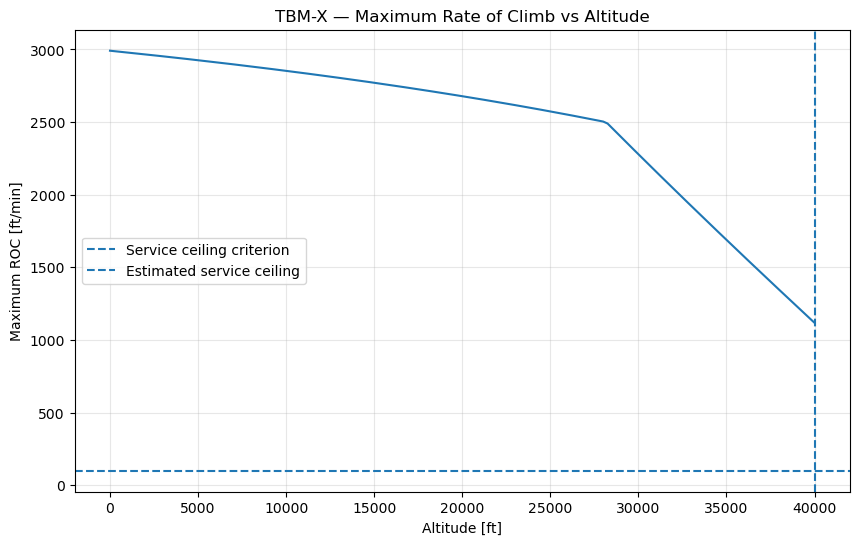

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    ceiling_results["altitude_ft"],
    ceiling_results["max_ROC_ft_min"]
)

plt.axhline(
    service_ceiling_ROC_ft_min,
    linestyle="--",
    label="Service ceiling criterion"
)

plt.axvline(
    service_ceiling_ft,
    linestyle="--",
    label="Estimated service ceiling"
)

plt.xlabel("Altitude [ft]")
plt.ylabel("Maximum ROC [ft/min]")
plt.title(
    "TBM-X — Maximum Rate of Climb vs Altitude"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**Absolute Ceiling**

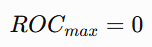

In [34]:
# ============================================================
# ABSOLUTE CEILING
# ============================================================

valid_absolute = ceiling_results[
    ceiling_results[
        "max_ROC_ft_min"
    ] >= 0
]

if len(valid_absolute) > 0:

    absolute_ceiling_ft = (
        valid_absolute[
            "altitude_ft"
        ].max()
    )

    print(
        f"Estimated absolute ceiling "
        f"≈ {absolute_ceiling_ft:.0f} ft"
    )

else:

    absolute_ceiling_ft = np.nan

Estimated absolute ceiling ≈ 40000 ft


**Performance Summary**

In [35]:
# ============================================================
# PERFORMANCE SUMMARY
# ============================================================

performance_summary = pd.DataFrame({
    "Parameter": [
        "MTOW",
        "Wing area",
        "Cruise speed",
        "Cruise altitude",
        "Stall speed",
        "Maximum L/D",
        "Best L/D speed",
        "Maximum ROC",
        "Speed at maximum ROC",
        "Maximum level-flight speed",
        "Service ceiling",
        "Absolute ceiling"
    ],

    "Value": [
        MTOW_kg,
        wing_area_m2,
        cruise_speed_kt,
        cruise_altitude_ft,
        stall_speed_kt,
        max_LD,
        best_LD_speed_kt,
        max_ROC_ft_min,
        speed_max_ROC_kt,
        max_level_speed_kt,
        service_ceiling_ft,
        absolute_ceiling_ft
    ],

    "Unit": [
        "kg",
        "m²",
        "kt",
        "ft",
        "kt",
        "-",
        "kt",
        "ft/min",
        "kt",
        "kt",
        "ft",
        "ft"
    ]
})

performance_summary

,Parameter,Value,Unit
0,MTOW,3400.000000,kg
1,Wing area,18.000000,m²
2,Cruise speed,300.000000,kt
3,Cruise altitude,25000.000000,ft
4,Stall speed,79.677581,kt
5,Maximum L/D,15.164536,-
6,Best L/D speed,183.618090,kt
7,Maximum ROC,2573.361287,ft/min
8,Speed at maximum ROC,139.899497,kt
9,Maximum level-flight speed,307.236181,kt


**Performance Diagnostics**

In [36]:
# ============================================================
# PERFORMANCE DIAGNOSTICS
# ============================================================

print("=== PERFORMANCE DIAGNOSTICS ===")

if P_excess_kW > 0:
    print("✓ Positive excess power at reference cruise condition.")
else:
    print("✗ Insufficient power at reference cruise condition.")

if max_ROC_ft_min > 0:
    print("✓ Aircraft has positive climb capability.")
else:
    print("✗ No positive climb capability.")

if service_ceiling_ft >= 0:
    print(
        "✓ Preliminary service ceiling identified."
    )
else:
    print(
        "⚠ Service ceiling could not be identified."
    )

if max_level_speed_kt > cruise_speed_kt:
    print(
        "✓ Maximum level-flight speed exceeds "
        "cruise design speed."
    )
else:
    print(
        "⚠ Maximum speed is below or near "
        "cruise design speed."
    )

=== PERFORMANCE DIAGNOSTICS ===
✓ Positive excess power at reference cruise condition.
✓ Aircraft has positive climb capability.
✓ Preliminary service ceiling identified.
✓ Maximum level-flight speed exceeds cruise design speed.


**Benchmark Comparison**

In [37]:
# ============================================================
# BENCHMARK COMPARISON
# ============================================================

benchmark_data = {
    "TBM960": {
        "MTOW_kg": 3454.0,
        "cruise_speed_kt": 329.8,
        "service_ceiling_ft": 31000.0,
        "ROC_ft_min": 1330.0
    },

    "TBM940": {
        "MTOW_kg": 3354.0,
        "cruise_speed_kt": 329.8,
        "service_ceiling_ft": 31000.0,
        "ROC_ft_min": 1330.0
    }
}

benchmark_df = pd.DataFrame(
    benchmark_data
).T

benchmark_df

,MTOW_kg,cruise_speed_kt,service_ceiling_ft,ROC_ft_min
TBM960,3454.0,329.8,31000.0,1330.0
TBM940,3354.0,329.8,31000.0,1330.0


**TBM-X vs Benchmark**

In [38]:
# ============================================================
# TBM-X VS TBM BENCHMARK
# ============================================================

tbmx_performance = {
    "MTOW_kg": MTOW_kg,
    "cruise_speed_kt": cruise_speed_kt,
    "service_ceiling_ft": service_ceiling_ft,
    "ROC_ft_min": max_ROC_ft_min
}

comparison = pd.DataFrame({
    "TBM-X": tbmx_performance,
    "TBM960": benchmark_df.loc[
        "TBM960"
    ]
})

comparison["Relative_Error"] = (
    (
        comparison["TBM-X"] -
        comparison["TBM960"]
    )
    /
    comparison["TBM960"]
)

comparison

,TBM-X,TBM960,Relative_Error
MTOW_kg,3400.000000,3454.0,-0.015634
cruise_speed_kt,300.000000,329.8,-0.090358
service_ceiling_ft,40000.000000,31000.0,0.290323
ROC_ft_min,2573.361287,1330.0,0.934858


**Performance Validation Plot**

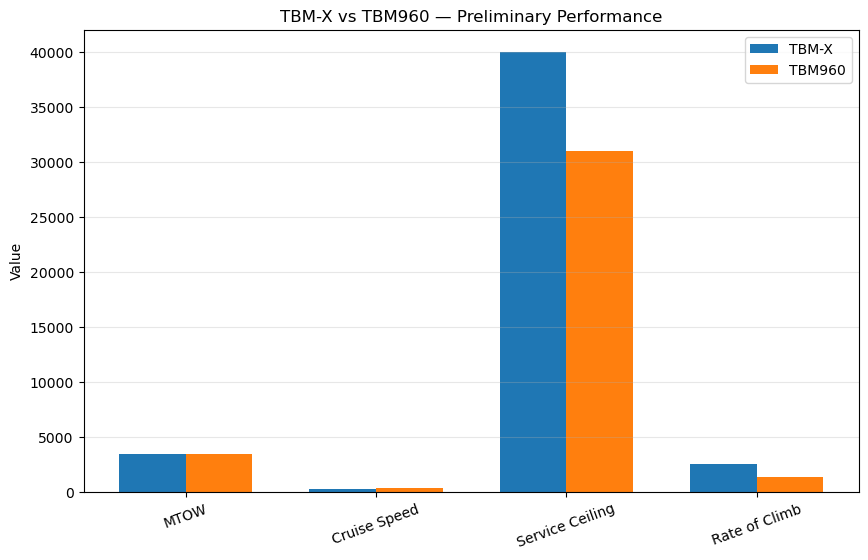

In [39]:
# ============================================================
# PERFORMANCE VALIDATION
# ============================================================

comparison_plot = pd.DataFrame({
    "Parameter": [
        "MTOW",
        "Cruise Speed",
        "Service Ceiling",
        "Rate of Climb"
    ],

    "TBM-X": [
        MTOW_kg,
        cruise_speed_kt,
        service_ceiling_ft,
        max_ROC_ft_min
    ],

    "TBM960": [
        benchmark_df.loc["TBM960", "MTOW_kg"],
        benchmark_df.loc["TBM960", "cruise_speed_kt"],
        benchmark_df.loc["TBM960", "service_ceiling_ft"],
        benchmark_df.loc["TBM960", "ROC_ft_min"]
    ]
})

x = np.arange(
    len(comparison_plot)
)

width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    comparison_plot["TBM-X"],
    width,
    label="TBM-X"
)

plt.bar(
    x + width/2,
    comparison_plot["TBM960"],
    width,
    label="TBM960"
)

plt.xticks(
    x,
    comparison_plot["Parameter"],
    rotation=20
)

plt.ylabel("Value")
plt.title(
    "TBM-X vs TBM960 — Preliminary Performance"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

**Normalized Benchmark Error**

In [40]:
# ============================================================
# NORMALIZED BENCHMARK ERROR
# ============================================================

comparison_error = comparison[
    "Relative_Error"
].copy()

comparison_error

MTOW_kg              -0.015634
cruise_speed_kt      -0.090358
service_ceiling_ft    0.290323
ROC_ft_min            0.934858
Name: Relative_Error, dtype: float64

**Performance Sensitivity: Engine Power**

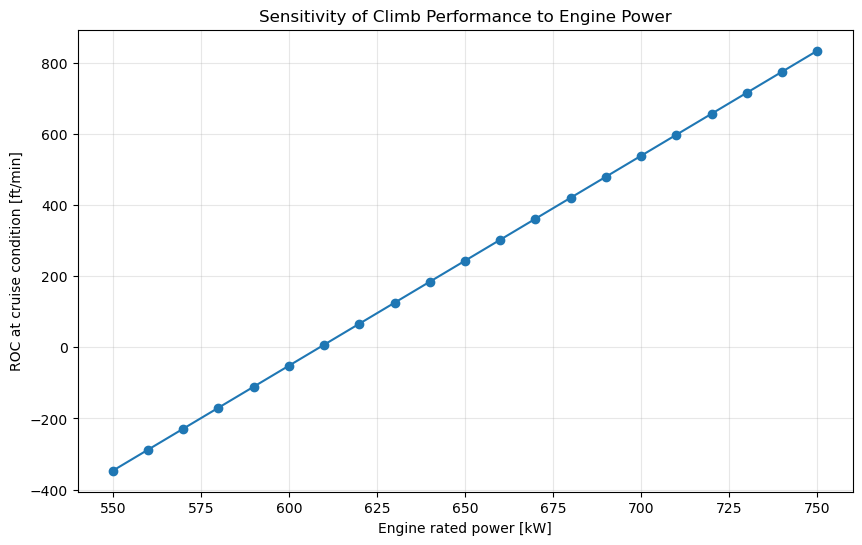

In [41]:
# ============================================================
# ENGINE POWER SENSITIVITY
# ============================================================

engine_power_values = np.linspace(
    550,
    750,
    21
)

roc_sensitivity = []

for power_kW in engine_power_values:

    prop_i = available_shaft_power(
        altitude_m=cruise_altitude_m,
        engine_rated_power_kW=power_kW
    )

    available_i = (
        prop_i[
            "available_shaft_power_kW"
        ]
    )

    excess_i = (
        available_i -
        P_required_kW
    )

    roc_i = (
        excess_i * 1000 /
        weight_N
    )

    roc_sensitivity.append(
        roc_i * 196.850394
    )

plt.figure(figsize=(10, 6))

plt.plot(
    engine_power_values,
    roc_sensitivity,
    marker="o"
)

plt.xlabel("Engine rated power [kW]")
plt.ylabel("ROC at cruise condition [ft/min]")
plt.title(
    "Sensitivity of Climb Performance to Engine Power"
)

plt.grid(True, alpha=0.3)

plt.show()

**Final Design Performance Vector**

In [42]:
# ============================================================
# FINAL PERFORMANCE VECTOR
# ============================================================

final_performance_vector = {
    "MTOW_kg": MTOW_kg,
    "wing_area_m2": wing_area_m2,
    "cruise_speed_kt": cruise_speed_kt,
    "cruise_altitude_ft": cruise_altitude_ft,
    "stall_speed_kt": stall_speed_kt,
    "max_LD": max_LD,
    "best_LD_speed_kt": best_LD_speed_kt,
    "max_ROC_ft_min": max_ROC_ft_min,
    "speed_max_ROC_kt": speed_max_ROC_kt,
    "max_level_speed_kt": max_level_speed_kt,
    "service_ceiling_ft": service_ceiling_ft,
    "absolute_ceiling_ft": absolute_ceiling_ft
}

final_performance_vector

{'MTOW_kg': 3400.0,
 'wing_area_m2': 18.0,
 'cruise_speed_kt': 300.0,
 'cruise_altitude_ft': 25000.0,
 'stall_speed_kt': np.float64(79.67758059874302),
 'max_LD': np.float64(15.164536266647021),
 'best_LD_speed_kt': np.float64(183.6180904522613),
 'max_ROC_ft_min': np.float64(2573.36128665485),
 'speed_max_ROC_kt': np.float64(139.8994974874372),
 'max_level_speed_kt': 307.2361809045226,
 'service_ceiling_ft': 40000.0,
 'absolute_ceiling_ft': 40000.0}

**Save Performance Results**

In [43]:
# ============================================================
# SAVE RESULTS
# ============================================================

output_dir = (
    PROJECT_ROOT /
    "outputs" /
    "performance"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

performance_file = (
    output_dir /
    "TBM_X_performance_summary.csv"
)

performance_summary.to_csv(
    performance_file,
    index=False
)

speed_file = (
    output_dir /
    "TBM_X_speed_performance.csv"
)

speed_results.to_csv(
    speed_file,
    index=False
)

ceiling_file = (
    output_dir /
    "TBM_X_ceiling_analysis.csv"
)

ceiling_results.to_csv(
    ceiling_file,
    index=False
)

print("Performance outputs saved:")
print(performance_file)
print(speed_file)
print(ceiling_file)

Performance outputs saved:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\outputs\performance\TBM_X_performance_summary.csv
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\outputs\performance\TBM_X_speed_performance.csv
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\outputs\performance\TBM_X_ceiling_analysis.csv


**Final Engineering Statement**

In [44]:
# ============================================================
# FINAL ENGINEERING STATEMENT
# ============================================================

print("""
TBM-X PERFORMANCE MODEL — ENGINEERING SUMMARY
----------------------------------------------

The performance model connects the aerodynamic and
propulsion models developed previously.

The aircraft performance is evaluated through:

    Available Power
          -
    Required Power
          =
    Excess Power

From excess power, the model estimates:

    • Rate of climb
    • Maximum climb performance
    • Maximum level-flight speed
    • Service ceiling
    • Absolute ceiling

The model also evaluates:

    • Stall speed
    • Maximum L/D
    • Best L/D speed
    • Power required vs speed
    • Performance sensitivity to engine power

Benchmark aircraft are used for validation,
not for forcing the TBM-X results toward
a predetermined answer.

The current model remains conceptual-level.
Engine, propeller and aerodynamic assumptions
must progressively be replaced or calibrated
using reliable benchmark and engineering data.
""")


TBM-X PERFORMANCE MODEL — ENGINEERING SUMMARY
----------------------------------------------

The performance model connects the aerodynamic and
propulsion models developed previously.

The aircraft performance is evaluated through:

    Available Power
          -
    Required Power
          =
    Excess Power

From excess power, the model estimates:

    • Rate of climb
    • Maximum climb performance
    • Maximum level-flight speed
    • Service ceiling
    • Absolute ceiling

The model also evaluates:

    • Stall speed
    • Maximum L/D
    • Best L/D speed
    • Power required vs speed
    • Performance sensitivity to engine power

Benchmark aircraft are used for validation,
not for forcing the TBM-X results toward
a predetermined answer.

The current model remains conceptual-level.
Engine, propeller and aerodynamic assumptions
must progressively be replaced or calibrated
using reliable benchmark and engineering data.



In [45]:
print("""
01 REQUIREMENTS
       │
       ▼
02 DATA / BENCHMARK
       │
       ▼
03 WEIGHT SIZING
       │
       ▼
04 MISSION
       │
       ▼
05 WEIGHT ↔ MISSION ITERATION
       │
       ▼
06 GEOMETRY
       │
       ▼
07 AERODYNAMICS
       │
       ├── CD0
       ├── CDi
       ├── Drag
       └── Required Power
                  │
                  ▼
08 PROPULSION
       │
       ├── Engine
       ├── Altitude
       ├── Propeller
       └── BSFC
                  │
                  ▼
09 PERFORMANCE
       │
       ├── Stall
       ├── Cruise
       ├── ROC
       ├── Vmax
       ├── Service Ceiling
       └── Absolute Ceiling
       """)


01 REQUIREMENTS
       │
       ▼
02 DATA / BENCHMARK
       │
       ▼
03 WEIGHT SIZING
       │
       ▼
04 MISSION
       │
       ▼
05 WEIGHT ↔ MISSION ITERATION
       │
       ▼
06 GEOMETRY
       │
       ▼
07 AERODYNAMICS
       │
       ├── CD0
       ├── CDi
       ├── Drag
       └── Required Power
                  │
                  ▼
08 PROPULSION
       │
       ├── Engine
       ├── Altitude
       ├── Propeller
       └── BSFC
                  │
                  ▼
09 PERFORMANCE
       │
       ├── Stall
       ├── Cruise
       ├── ROC
       ├── Vmax
       ├── Service Ceiling
       └── Absolute Ceiling
       
